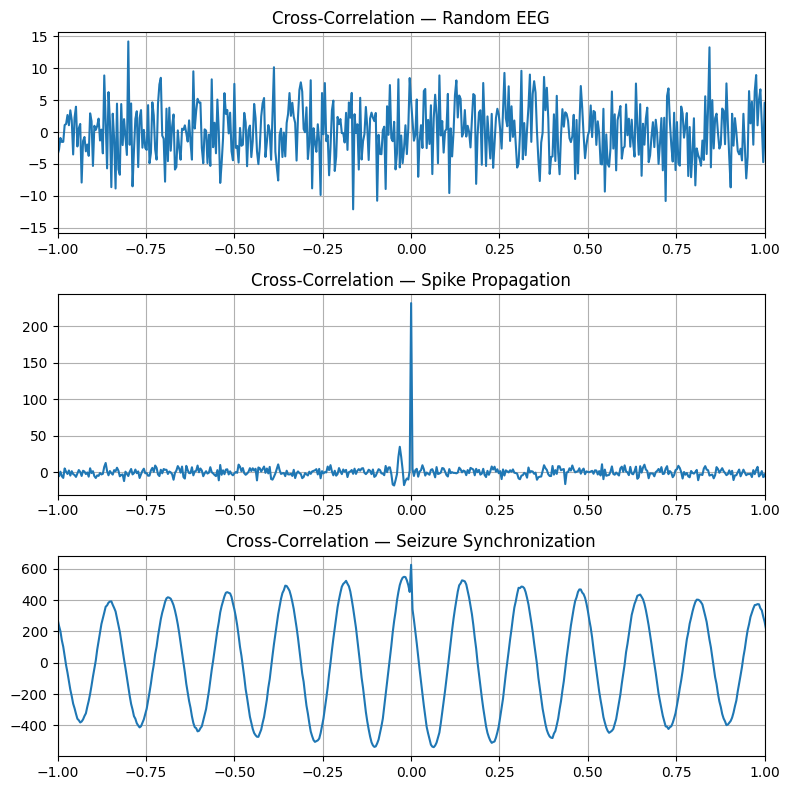

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, gausspulse
#correlate → compute cross-correlation
#gausspulse → generate spike-like transient waveform

# PARAMETERS
Fs = 250
T  = 10
t  = np.arange(0, T, 1/Fs)    #step size= 1/Fs= 1/250= 0.004
N  = len(t)

# ======================================================
# CASE 1 — Random EEG (independent channels)
# Generate Gaussian white noise of amplitude 15 µV
# This represents background spontaneous cortical activity
# ======================================================
x1 = 15*np.random.randn(N)
x2 = 15*np.random.randn(N)

Rr = correlate(x1, x2, mode='full')/N ## this computes cross-correlation
# mode='full', calculate all possible lags
lags = np.arange(-N+1, N)

# ======================================================
# CASE 2 — Spike propagation
# ======================================================
x1s = 15*np.random.randn(N)
x2s = np.copy(x1s)

spike_time = 3 #spike occurs at 3 s in Ch-1
delay = 0.03     # 30 ms propagation

# Convert time--> sample index
i1 = int(round(spike_time*Fs))
i2 = int(round((spike_time+delay)*Fs))

spike = gausspulse(np.arange(-5,6)/Fs, fc=25, bw=0.6) # short Gaussian-shaped oscillatory pulse
# of duration 40ms

x1s[i1-5:i1+6] = x1s[i1-5:i1+6] + 120*spike  #Adds spike around index i1- Range: i1-5 to i1+6 → 11 samples
x2s[i2-5:i2+6] = x2s[i2-5:i2+6] + 120*spike

Rs = correlate(x1s, x2s, mode='full')/N

# ======================================================
# CASE 3 — Seizure synchronization
# ======================================================
x1z = 15*np.random.randn(N)
x2z = np.copy(x1z)

win = (t>=6) & (t<=9) # Define Seizure window
freq = 6 # rhythmic discharge at 6 Hz

x1z[win] = x1z[win] + 60*np.sin(2*np.pi*freq*t[win])
x2z[win] = x2z[win] + 60*np.sin(2*np.pi*freq*(t[win]-0.02)) # phase shifted by 20 ms

Rz = correlate(x1z, x2z, mode='full')/N
lag_time = lags/Fs # sample delay → physical time delay

# ======================================================
# PLOTS
# ======================================================
plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
plt.plot(lag_time, Rr)
plt.title('Cross-Correlation — Random EEG')
plt.xlim([-1,1])
plt.grid()

plt.subplot(3,1,2)
plt.plot(lag_time, Rs)
plt.title('Cross-Correlation — Spike Propagation')
plt.xlim([-1,1])
plt.grid()

plt.subplot(3,1,3)
plt.plot(lag_time, Rz)
plt.title('Cross-Correlation — Seizure Synchronization')
plt.xlim([-1,1])
plt.grid()

plt.tight_layout()
plt.show()